Running Courtemanche on [400, 400] Grid: 100%|██████████| 3000/3000 [00:03<00:00, 973.52it/s]


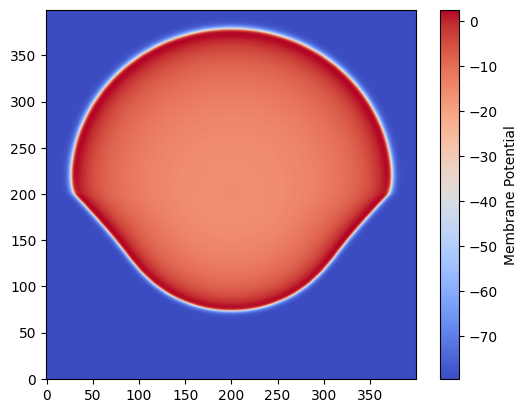

In [14]:
import matplotlib.pyplot as plt
import finitewave as fw
import numpy as np

# Set up pre-pacing protocol to stabilize the model before the main simulation:
stim_prepacing = fw.StimSingleCell(dt=0.005)
stim_prepacing.add_stim(n_beats=30, cycle_length=1000., curr_value=20., duration=2.)
stim_prepacing.add_stim(n_beats=30, cycle_length=500., curr_value=20., duration=2.)
# Initialize the Courtemanche model and apply the pre-pacing protocol: 
courtemanche = fw.Courtemanche()
courtemanche.prepacing(stim_prepacing)

# create a tissue grid of size 400x400:
n = 400
tissue = fw.CardiacTissue([n, n], dr=0.1)
tissue.conductivity = np.ones((n, n))
tissue.conductivity[:n//2] = 0.5
# tissue.mesh = 1 + (np.random.random((n, n)) < 0.2).astype(int)  # add some random noise to the mesh
# tissue.fibers = np.zeros((n, n, 2))
# tissue.fibers[:, :, 0] = np.cos(np.pi / 4)  # x-component of fiber direction
# tissue.fibers[:, :, 1] = np.sin(np.pi / 4)

# set up stimulation parameters:
stim_sequence = fw.StimSequence()
stim_sequence.add_stim(fw.StimVoltageCoord(time=0, volt_value=1,
                                           x_min=n//2 - 3, x_max=n//2 + 3,
                                           y_min=n//2 - 3, y_max=n//2 + 3))

# create model object and set up parameters:
simulation = fw.CardiacSimulation(dt=0.01, t_max=30, backend="mlx")
simulation.cardiac_model = courtemanche
simulation.cardiac_tissue = tissue
simulation.stim_sequence = stim_sequence

# run the model:
simulation.run()

# show the potential map at the end of calculations:
u = simulation.cardiac_model.output("u")
u[tissue.mesh == 2] = np.nan  # mask out the non-tissue regions for better visualization
cmap = plt.get_cmap('coolwarm')
cmap.set_bad(color='black')  # set the color for NaN values (non-tissue regions)
fig = plt.figure()
plt.imshow(u, cmap=cmap, origin="lower")
plt.colorbar(label="Membrane Potential")
plt.show()

fig.savefig("low_cond_medium_2d.png", dpi=300)

In [1]:
import matplotlib.pyplot as plt
import finitewave as fw


def run_model(model, t_max):
    # create a tissue of size 100x10 with cardiomycytes:
    n = 100
    m = 1
    tissue = fw.CardiacTissue([n, m], dr=0.25)

    # set up stimulation parameters:
    stim_sequence = fw.StimSequence()
    stim_sequence.add_stim(fw.StimVoltageCoord(time=0, volt_value=1,
                                               x_min=0, x_max=5,
                                               y_min=0, y_max=m))

    action_pot_tracker = fw.ActionPotentialTracker()
    action_pot_tracker.node_inds = [[n//2, 0]]
    action_pot_tracker.step = 1

    tracker_sequence = fw.TrackerSequence()
    tracker_sequence.add_tracker(action_pot_tracker)

    # create model object and set up parameters:
    simulation = fw.CardiacSimulation(dt=0.01, t_max=t_max, backend="numba")
    simulation.cardiac_model = model
    simulation.cardiac_tissue = tissue
    simulation.stim_sequence = stim_sequence
    simulation.tracker_sequence = tracker_sequence

    # run the model:
    simulation.run()

    return action_pot_tracker.tracking_times, action_pot_tracker.output

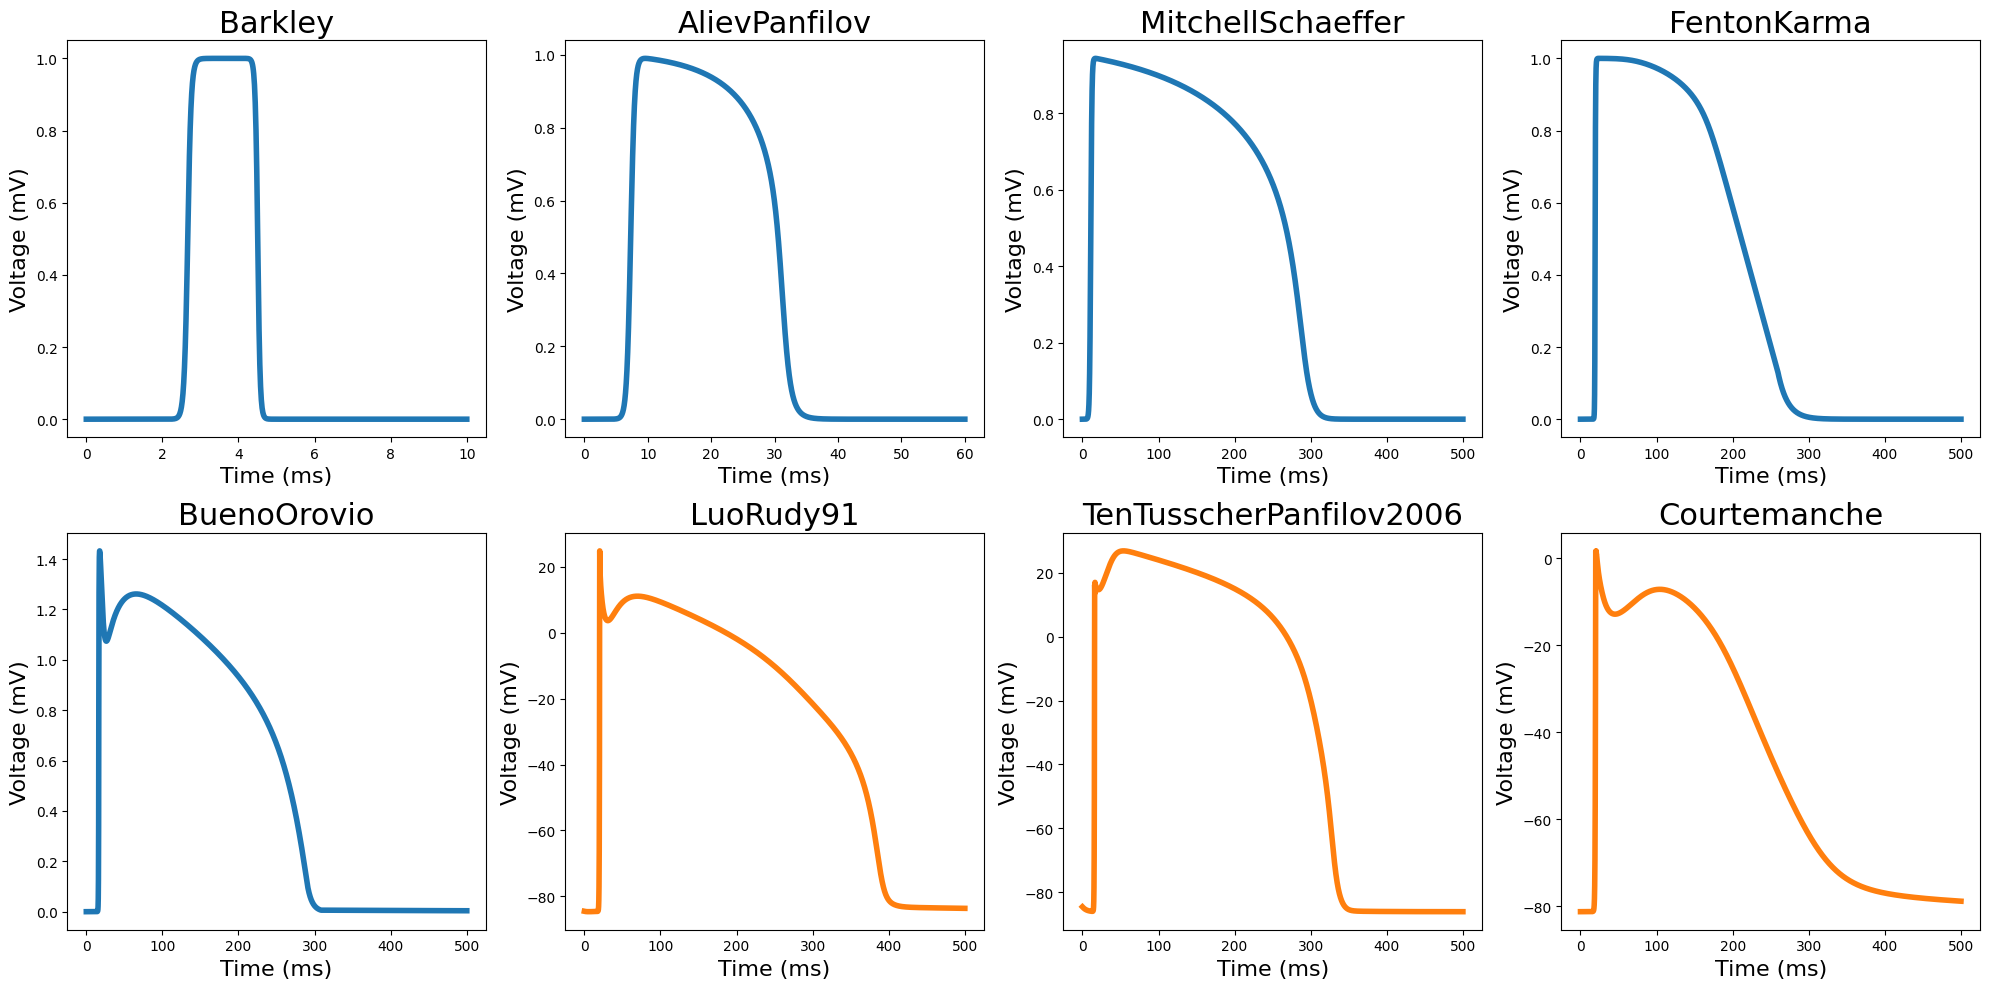

In [4]:
models = [fw.Barkley(), fw.AlievPanfilov(), fw.MitchellSchaeffer(), 
          fw.FentonKarma(), fw.BuenoOrovio(), fw.LuoRudy91(),
          fw.TenTusscherPanfilov2006(), fw.Courtemanche()]
colors = ["tab:blue", "tab:blue", "tab:blue", "tab:blue", "tab:blue",
          "tab:orange", "tab:orange", "tab:orange"]

t_max = [10, 60, 500, 500, 500, 500, 500, 500]

# ap_times = []
# ap_values = []
# for i, model in enumerate(models):
#     ap_times_, ap_values_ = run_model(model, t_max=t_max[i])

#     ap_times.append(ap_times_)
#     ap_values.append(ap_values_)

fig, axs = plt.subplots(2, 4, figsize=(20, 10))
for i, model in enumerate(models):
    ax = axs[i//4, i%4]
    ax.plot(ap_times[i], ap_values[i], lw=4, color=colors[i])
    ax.set_title(model.__class__.__name__, fontsize=22)
    ax.set_xlabel("Time (ms)", fontsize=16)
    ax.set_ylabel("Voltage (mV)", fontsize=16)
plt.tight_layout()
plt.show()

fig.savefig("fw_models.png", dpi=300)

Running TenTusscherPanfilov2006 on (400, 100) Grid: 100%|██████████| 7000/7000 [00:03<00:00, 2020.98it/s]


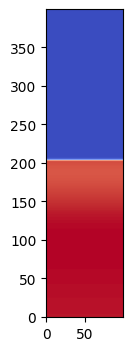

<Figure size 640x480 with 0 Axes>

In [16]:
import matplotlib.pyplot as plt
import finitewave as fw

n, m = 400, 100
# set up stimulation parameters:
stim_sequence = fw.StimSequence()
stim_sequence.add_stim(fw.StimVoltageCoord(time=0, volt_value=1,
                                           x_min=0, x_max=3,
                                           y_min=0, y_max=m))

# create model object and set up parameters:
simulation = fw.CardiacSimulation(dt=0.01, t_max=70, backend="jax")
simulation.cardiac_model = fw.TenTusscherPanfilov2006()
simulation.cardiac_tissue = fw.CardiacTissue((n, m), dr=0.25)
simulation.stim_sequence = stim_sequence

# run the model:
simulation.run()

fig = plt.figure(figsize=(12, 4))
plt.imshow(simulation.cardiac_model.output("u"), cmap="coolwarm", origin="lower")
plt.show()
plt.tight_layout()
fig.savefig("ten_tusscher_wave.png", dpi=300)
